In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Simulation parameters
T = 5000                 # time steps
B = 100                  # total beds
lambda_arrival = 6   # average arrivals per step
avg_stay = 10            # average stay time

# Behavioral parameters
alpha = 0.2  # selfishness (0 = cooperative)
beta = 0.5               # congestion effect

In [21]:
Q = 0                    # queue size
O = 0                    # occupied beds

queue_history = []
occupancy_history = []
avalanches = []

In [22]:
for t in range(T):

    # --- Step 1: Arrivals (Noise) ---
    arrivals = np.random.poisson(lambda_arrival)
    Q += arrivals

    # --- Step 2: Admission ---
    admit = min(Q, B - O)
    Q -= admit
    O += admit

    # --- Step 3: Discharge (Core dynamics) ---
    if O > 0:
        D_base = O / avg_stay
    else:
        D_base = 0

    utilization = O / B

    D = D_base * (1 - alpha) * (1 - beta * utilization)
    D = int(max(D, 0))  # ensure non-negative integer

    # --- Step 4: Update ---
    O -= D
    if O < 0:
        O = 0

    # --- Store data ---
    queue_history.append(Q)
    occupancy_history.append(O)

    # --- Avalanche detection ---
    if t > 0:
        delta_q = queue_history[t] - queue_history[t-1]
        if delta_q > 0:
            avalanches.append(delta_q)

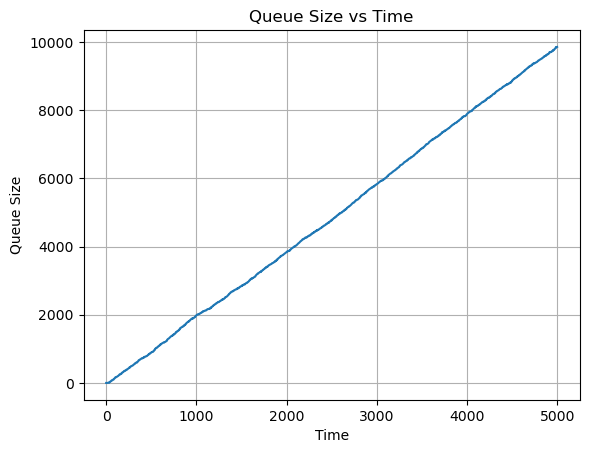

In [23]:
plt.figure()
plt.plot(queue_history)
plt.title("Queue Size vs Time")
plt.xlabel("Time")
plt.ylabel("Queue Size")
plt.grid()
plt.show()

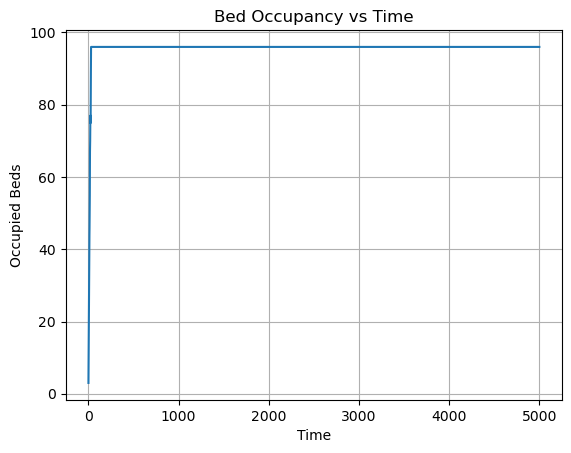

In [24]:
plt.figure()
plt.plot(occupancy_history)
plt.title("Bed Occupancy vs Time")
plt.xlabel("Time")
plt.ylabel("Occupied Beds")
plt.grid()
plt.show()

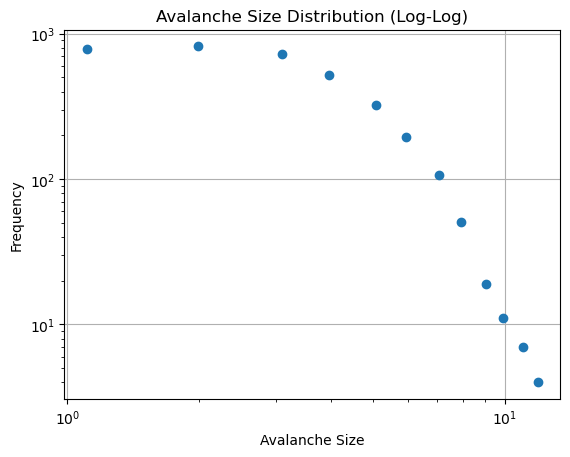

In [25]:
# Remove zeros if any
avalanches = [a for a in avalanches if a > 0]

# Histogram (log-log)
counts, bins = np.histogram(avalanches, bins=50)

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure()
plt.loglog(bin_centers, counts, 'o')
plt.title("Avalanche Size Distribution (Log-Log)")
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.grid()
plt.show()